*Last update: March 2025*  
*Contact:* fdrs@ifrc.org or dirk.merkhof@ifrc.org  
*FDRS focal point:* Dirk van den Merkhof, FDRS Data Analyst

# How to deal with Missing Values? FDRS imputation methodology in python
-----------


The FDRS is ambitious and wide reaching. Although the data quality and reporting are improving each year, data is missing for some National Societies. As a result, some data fluctuations may be misleading: trend lines can drop for a given year when there is missing data, and some National Societies are excluded from the total and then appear again in another year.In order to better represent the network and better count everyone, FDRS implement every year data imputation techniques. 

The purpose of this notebook is to apply the method selected by the FDRS team and to interact with the FDRS backoffice with a post method to publish the imputed values. 
The ingested data is  replicated and displayed on the website https://data.ifrc.org/FDRS/ and used in FDRS research such as [Everyone count report](https://data-api.ifrc.org/documents/noiso/Everyone%20Counts_Special%20Edition%20Mid-Term%20Review%20of%20Strategy%202030_English.pdf). 

Therefore this is not a research notebook but a production notebook. It aims to simply expose the FDRS methodology of imputation step by step. A related python script has been created: [imputing.py]() which allows to launch this methodology once. 

The approach chosen was to replace missing data from 2019 and onwards, as well as to apply two different techniques according to the indicator categories, in the previous years all NSs reported their data then no input technique was employed.   

The imputing applies only to main indicators and does not apply to disaggregated levels to maintain consistency across years. A detailed description of the methodology is available in the pdf [Missing Data]()


## Table of Contents


1. [Import Necessary Packages](#import-packages)
2. [Selecting Production and Staging Environment](#environment-selection)
3. [Data Retrieval](#data-retrieval)
4. [Data Imputation](#data-imputation)
5. [POST Method to Update Back-end](#post-method)

## 1. Imports and Initial Configurations

In [1]:
import os
import sys
import time
import warnings
from datetime import datetime
import pandas as pd
import numpy as np
import requests
from pandas import json_normalize
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import math

warnings.filterwarnings('ignore')
#set working directory
os.chdir(r"C:\Users\dirk.merkhof\OneDrive - IFRC\Documents\git\fdrs_imputing_missing_values\notebooks")

## 2. Configuration Loading

Before proceeding, let's select the desired environment. This will determine the configuration settings we'll use throughout the notebook.


In [2]:
def select_environment(config_prod_path, config_staging_path):
    """Select the environment and load the respective configuration."""
    env = ''
    #ask the user whether they want to select staging or prod
    while env not in ['staging', 'prod']:
        env = input("Select environment ('staging' or 'prod'): ").lower()
        #if they select prod
        if env == 'prod':
            confirm = input("WARNING: You've selected the PRODUCTION environment. Are you sure? (yes/no) ")
            #confirm, else staging
            if confirm.lower() != 'yes':
                print("Switching to 'staging' by default for safety.")
                env = 'staging'
    #open and load the config file            
    try:
        with open(config_prod_path if env == 'prod' else config_staging_path, 'r') as file:
            return json.load(file)
    except FileNotFoundError:
        raise Exception(f"Configuration file for {env} not found.")

Configuration

In [3]:
config_prod_path = '../src/config/config_prod.json'
config_staging_path = '../src/config/config_staging.json'
#open and load the config file
config = select_environment(config_prod_path, config_staging_path)
print(f"Loaded configuration for {config['ENV']} environment.")
user_email = input('Please provide your FDRS data analyst email: ')
year=int(input('Please provide the year you would like to impute for: '))

Loaded configuration for staging environment.


## 3. Data Retrieval


### 3.1 Import necessary modules for data retrieval

In [4]:
#This is for adding src and data to the path, to load config and secondary code, fdrsapi
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(os.path.join(module_path, "src", "data"))
from fdrsapi import api_function, baseline, api_function_imputed

In [5]:
#Generate fdrs codebook and store it in references folder

base_url = config['BASE_URL']
KPI = json_normalize(data=requests.get(f"{base_url}indicator?apiKey={config['API_KEY_PUBLIC']}").json())
codebook_path = os.path.join('..', 'references', 'codebook.xlsx')
KPI.to_excel(codebook_path)
codebook = pd.read_excel(codebook_path)

Add branches for 2024 below

In [6]:
codebook = pd.read_excel(r"..\references\codebook.xlsx")
#We scan for NS Reach - CPD to find the relevant total KPIs for reach, and we ad Train and DonBlood
kpi_reach = codebook.query('KPI_Note == "NS Reach - CPD"')["KPI_Code"].to_list() + ["KPI_TrainFA_Tot", "KPI_DonBlood_Tot"]
#metadata kpis are like submitted, validated
metadata_kpis = codebook.query('KPI_Note == "Metadata"')["KPI_Code"].tolist()
#gov KPIs
kpi_gov_code = ["KPI_GB_Tot", "KPI_PeopleVol_Tot", "KPI_PStaff_Tot", "KPI_noLocalUnits"]
#finance KPIs
kpi_fi_code = ["KPI_IncomeLC_CHF", "KPI_expenditureLC_CHF"]

exclude_kpis = ["KPI_Year", "DON_Code", "KPI_Id"]
metadata_kpis = [kpi for kpi in metadata_kpis if kpi not in exclude_kpis]
kpi_code = kpi_reach + kpi_gov_code + kpi_fi_code + metadata_kpis

In [7]:
#counting nb of considered KPIs
print("number of total KPI considered:", len(kpi_code)-2)

number of total KPI considered: 50


### 3.2 Get data from FDRS API

In [8]:
#select relevant years (should only be 4 consecutive years, or imputing will not tke the right average)
years = [str(year) for year in range(year-3,year+1)]
#gets published data from the entities (basic info) and KpiValue (KPIs and their values) endpoint
time_series = api_function(years, kpi_code, config)
original_data = time_series.copy()
original_data

,KPI_DON_code,NSO_DON_name,NSO_ZON_name,iso_3,KPI_Year,KPI ID,KPI_ClimateHeat_CPD,KPI_Climate_CPD,KPI_Completion,KPI_DonBlood_Tot,...,KPI_ReachM_CPD,KPI_ReachRCRCEd_CPD,KPI_ReachSI_CPD,KPI_ReachS_CPD,KPI_ReachWASH_CPD,KPI_TrainFA_Tot,KPI_WasSubmitted,KPI_expenditureLC_CHF,KPI_noLocalUnits,validated
0,DAD001,Andorran Red Cross,Europe and Central Asia,AND,2020.0,DAD0012020.0,NaN,NaN,90.0,NaN,...,NaN,NaN,NaN,NaN,NaN,2126.0,1.0,1763116.0,1.0,1.0
1,DAD001,Andorran Red Cross,Europe and Central Asia,AND,2021.0,DAD0012021.0,0.0,NaN,90.0,1426.0,...,NaN,NaN,0.0,NaN,NaN,3508.0,1.0,2319042.0,1.0,1.0
2,DAD001,Andorran Red Cross,Europe and Central Asia,AND,2022.0,DAD0012022.0,72.0,NaN,100.0,1450.0,...,187.0,14.0,NaN,NaN,NaN,3582.0,1.0,2595220.0,1.0,1.0
3,DAD001,Andorran Red Cross,Europe and Central Asia,AND,2023.0,DAD0012023.0,NaN,NaN,90.0,1461.0,...,NaN,NaN,NaN,NaN,NaN,3141.0,1.0,2150182.0,1.0,1.0
4,DAE001,Red Crescent Society of the United Arab Emirates,Middle East and North Africa,ARE,2020.0,DAE0012020.0,NaN,NaN,80.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,11.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,DZM001,Zambia Red Cross Society,Africa,ZMB,2023.0,DZM0012023.0,NaN,51363.0,95.0,NaN,...,76085.0,300.0,NaN,8765.0,670826.0,3786.0,1.0,2757021.0,61.0,1.0
764,DZW001,Zimbabwe Red Cross Society,Africa,ZWE,2020.0,DZW0012020.0,NaN,NaN,80.0,NaN,...,2408.0,NaN,67408.0,8169.0,787165.0,7823.0,1.0,3380148.0,157.0,0.0
765,DZW001,Zimbabwe Red Cross Society,Africa,ZWE,2021.0,DZW0012021.0,NaN,66302.0,100.0,NaN,...,1966.0,NaN,98386.0,62.0,77623.0,27376.0,1.0,3736596.0,132.0,1.0
766,DZW001,Zimbabwe Red Cross Society,Africa,ZWE,2022.0,DZW0012022.0,NaN,57721.0,100.0,NaN,...,6191.0,NaN,13759.0,1016.0,65041.0,37613.0,1.0,9951470.0,132.0,1.0


### 3.3 Analyzing FDRS data

In [9]:
# Initialize a DataFrame to store the counts -> meta data analysis
metadata_counts = pd.DataFrame()

# Loop over each metadata KPI
for kpi in metadata_kpis:
    if "Date" in kpi:  # Check if the KPI is a date indicator
        yes_count = time_series[time_series[kpi].notna()].groupby('KPI_Year').size()
    else:
        yes_count = time_series[time_series[kpi] == 1.0].groupby('KPI_Year').size()

    no_count = time_series[time_series[kpi] == 0.0].groupby('KPI_Year').size()
    na_count = time_series[time_series[kpi].isna()].groupby('KPI_Year').size()
    
    # Construct a temporary DataFrame and append it to the main DataFrame
    temp_df = pd.DataFrame({
        'KPI': kpi,
        'True': yes_count,
        'False': no_count,
        'NA': na_count
    }).reset_index()
    
    metadata_counts = metadata_counts._append(temp_df, ignore_index=True)

# Pivot the dataframe for a better view
pivot_metadata_counts = metadata_counts.pivot(index='KPI', columns='KPI_Year')

# Display the metadata counts table
# Specify the order of KPIs to display at the top
priority_kpis = ['KPI_WasSubmitted', 'validated']

# Reorder the index to have priority KPIs at the top
pivot_metadata_counts = pivot_metadata_counts.reindex(priority_kpis + [kpi for kpi in pivot_metadata_counts.index if kpi not in priority_kpis])

# Display the pivoted table for comparison
pivot_metadata_counts


True                       False                \
KPI_Year                2020.0 2021.0 2022.0 2023.0 2020.0 2021.0 2022.0   
KPI                                                                        
KPI_WasSubmitted         177.0  173.0  183.0  171.0    2.0    8.0    NaN   
validated                135.0  167.0  162.0  135.0   44.0   14.0   21.0   
KPI_Completion             NaN    NaN    NaN    4.0    3.0    1.0    3.0   
KPI_FillInRate             NaN    1.0    NaN    NaN    3.0    1.0    3.0   
KPI_FirstSubmitDate      178.0  179.0  180.0  171.0    NaN    NaN    NaN   
KPI_NSFP_PublishDate     172.0    NaN    NaN    NaN    NaN    NaN    NaN   
KPI_NSFP_StartDate       173.0  177.0  174.0  172.0    NaN    NaN    NaN   
KPI_NSFP_SubmitDate      173.0  175.0  169.0  154.0    NaN    NaN    NaN   
KPI_NSFP_ValidationDate  134.0  172.0  152.0  151.0    NaN    NaN    NaN   
KPI_NSFP_WasPublished    169.0  165.0  161.0  151.0    9.0   12.0   13.0   
KPI_NSFP_WasStarted      173.0  177.0  174.0  172.0    NaN    NaN    NaN   
KPI_NSFP_WasSubmitted    168.0  166.0  167.0  151.0    7.0   11.0    7.0   
KPI_NSFP_WasValidated    130.0  163.0  162.0  141.0    9.0   11.0   12.0   
KPI_NSGS_PublishDate     177.0    NaN    NaN    NaN    NaN    NaN    NaN   
KPI_NSGS_StartDate       179.0  181.0  183.0  180.0    NaN    NaN    NaN   
KPI_NSGS_SubmitDate      175.0  175.0  177.0  166.0    NaN    NaN    NaN   
KPI_NSGS_ValidationDate  129.0  171.0  141.0  172.0    NaN    NaN    NaN   
KPI_NSGS_WasPublished    173.0  171.0  177.0  168.0    6.0   10.0    6.0   
KPI_NSGS_WasStarted      179.0  181.0  183.0  180.0    NaN    NaN    NaN   
KPI_NSGS_WasSubmitted    176.0  173.0  183.0  169.0    3.0    8.0    NaN   
KPI_NSGS_WasValidated    128.0  162.0  160.0  157.0    4.0    9.0   11.0   
KPI_NSR_PublishDate      172.0    1.0    NaN    NaN    NaN    NaN    NaN   
KPI_NSR_StartDate        178.0  181.0  180.0  167.0    NaN    NaN    NaN   
KPI_NSR_SubmitDate       174.0  176.0  177.0  165.0    NaN    NaN    NaN   
KPI_NSR_ValidationDate   121.0  173.0  143.0  165.0    NaN    NaN    NaN   
KPI_NSR_WasPublished     170.0  167.0  167.0  162.0    7.0   14.0   13.0   
KPI_NSR_WasStarted       178.0  181.0  180.0  167.0    NaN    NaN    NaN   
KPI_NSR_WasSubmitted     171.0  169.0  177.0  163.0    6.0   11.0    3.0   
KPI_NSR_WasValidated     121.0  165.0  160.0  150.0    6.0   12.0   10.0   

                                   NA                       
KPI_Year                2023.0 2020.0 2021.0 2022.0 2023.0  
KPI                                                         
KPI_WasSubmitted          17.0   13.0   11.0    9.0    4.0  
validated                 57.0   13.0   11.0    9.0    NaN  
KPI_Completion             2.0    NaN    NaN    NaN    NaN  
KPI_FillInRate             1.0    NaN    NaN    NaN    NaN  
KPI_FirstSubmitDate        NaN   14.0   13.0   12.0   21.0  
KPI_NSFP_PublishDate       NaN   20.0  192.0  192.0  192.0  
KPI_NSFP_StartDate         NaN   19.0   15.0   18.0   20.0  
KPI_NSFP_SubmitDate        NaN   19.0   17.0   23.0   38.0  
KPI_NSFP_ValidationDate    NaN   58.0   20.0   40.0   41.0  
KPI_NSFP_WasPublished     30.0   14.0   15.0   18.0   11.0  
KPI_NSFP_WasStarted        9.0   19.0   15.0   18.0   11.0  
KPI_NSFP_WasSubmitted     30.0   17.0   15.0   18.0   11.0  
KPI_NSFP_WasValidated     40.0   53.0   18.0   18.0   11.0  
KPI_NSGS_PublishDate       NaN   15.0  192.0  192.0  192.0  
KPI_NSGS_StartDate         NaN   13.0   11.0    9.0   12.0  
KPI_NSGS_SubmitDate        NaN   17.0   17.0   15.0   26.0  
KPI_NSGS_ValidationDate    NaN   63.0   21.0   51.0   20.0  
KPI_NSGS_WasPublished     12.0   13.0   11.0    9.0   12.0  
KPI_NSGS_WasStarted        NaN   13.0   11.0    9.0   12.0  
KPI_NSGS_WasSubmitted     11.0   13.0   11.0    9.0   12.0  
KPI_NSGS_WasValidated     23.0   60.0   21.0   21.0   12.0  
KPI_NSR_PublishDate        NaN   20.0  191.0  192.0  192.0  
KPI_NSR_StartDate          NaN   14.0   11.0   12.0   25.0  
KPI_NSR

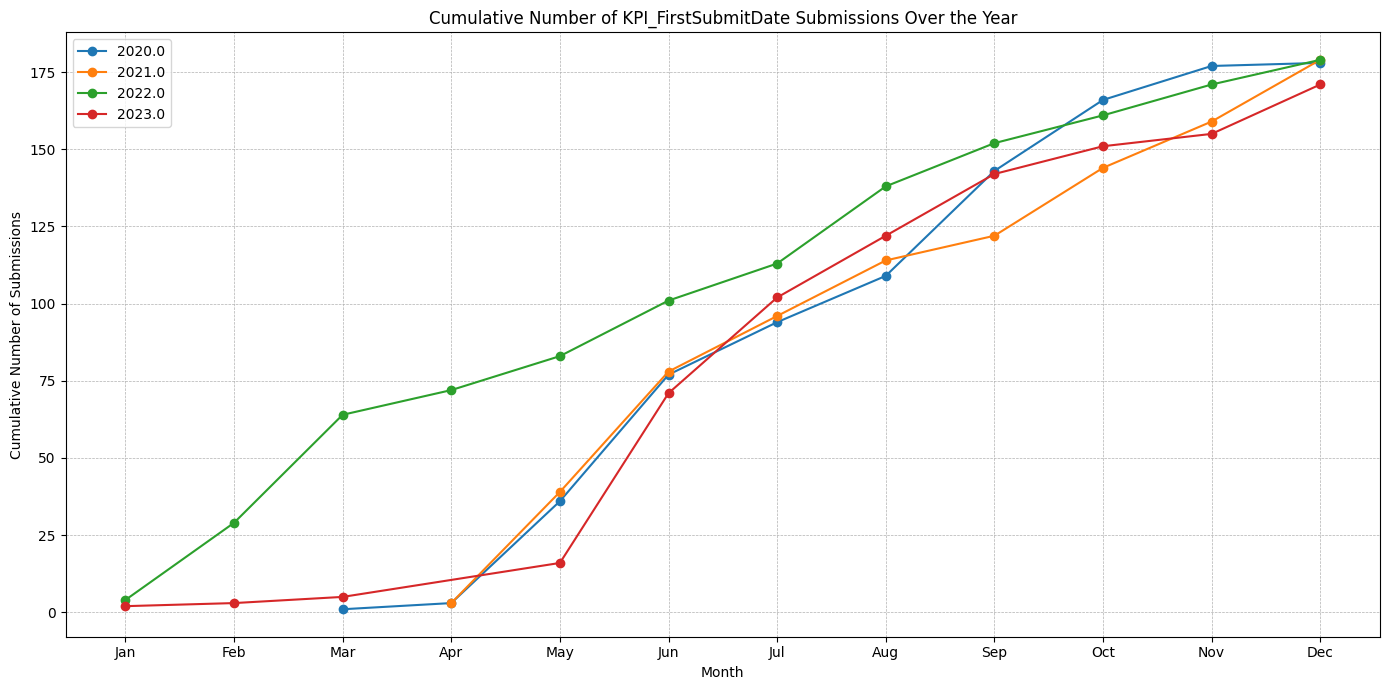

In [10]:
#Analyse when the data has been submitted
time_series['KPI_FirstSubmitDate'] = pd.to_datetime(time_series['KPI_FirstSubmitDate'], errors='coerce')

# Extract month
time_series['Month'] = time_series['KPI_FirstSubmitDate'].dt.month

# Group by year and month, then compute the cumulative count
grouped_cumulative = time_series.groupby(['KPI_Year', 'Month']).size().groupby(level=0).cumsum().reset_index(name='Cumulative Count')

# Plot
plt.figure(figsize=(14, 7))
for year1 in time_series['KPI_Year'].unique():
    subset = grouped_cumulative[grouped_cumulative['KPI_Year'] == year1]
    plt.plot(subset['Month'], subset['Cumulative Count'], label=year1, marker='o')

plt.title('Cumulative Number of KPI_FirstSubmitDate Submissions Over the Year')
plt.xlabel('Month')
plt.ylabel('Cumulative Number of Submissions')
plt.xticks(np.arange(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


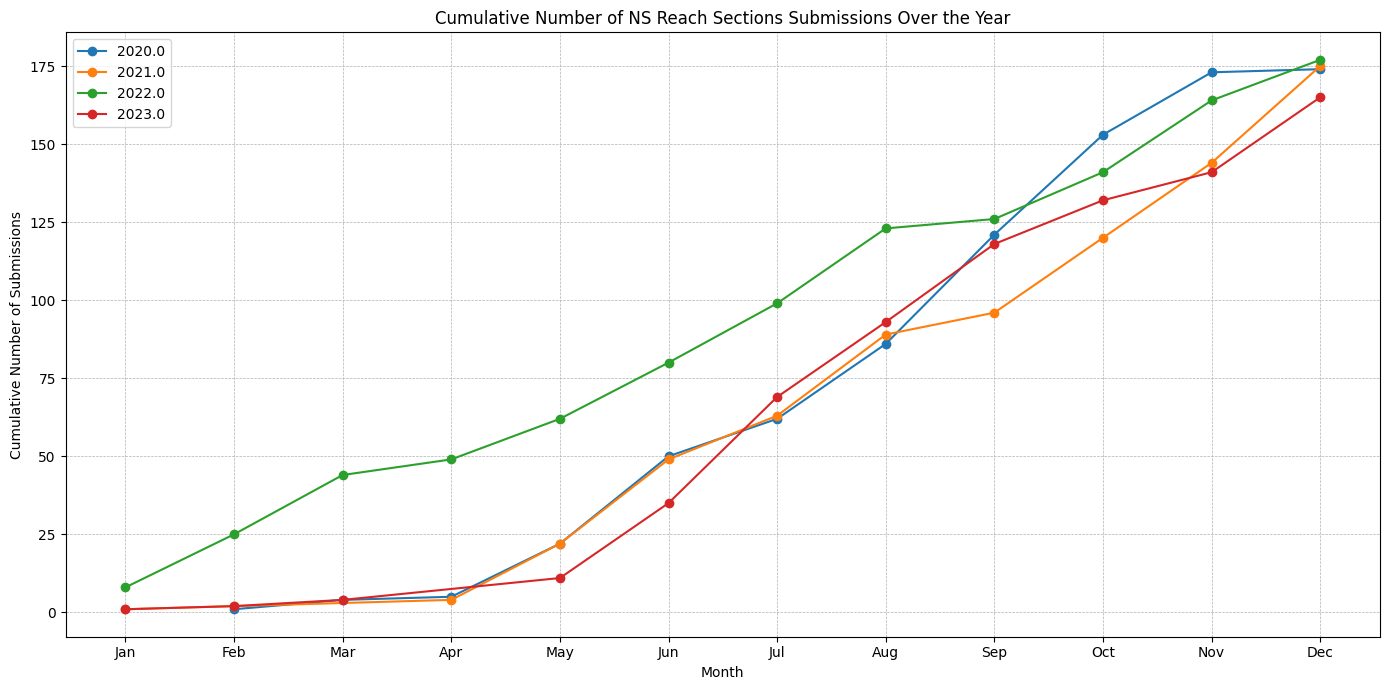

In [11]:
#Analyse when the reach data has been submitted
time_series['KPI_NSR_SubmitDate'] = pd.to_datetime(time_series['KPI_NSR_SubmitDate'], errors='coerce')


# Extract month
time_series['Month'] = time_series['KPI_NSR_SubmitDate'].dt.month

# Group by year and month, then compute the cumulative count
grouped_cumulative = time_series.groupby(['KPI_Year', 'Month']).size().groupby(level=0).cumsum().reset_index(name='Cumulative Count')

# Plot
plt.figure(figsize=(14, 7))
for year1 in time_series['KPI_Year'].unique():
    subset = grouped_cumulative[grouped_cumulative['KPI_Year'] == year1]
    plt.plot(subset['Month'], subset['Cumulative Count'], label=year1, marker='o')

plt.title('Cumulative Number of NS Reach Sections Submissions Over the Year')
plt.xlabel('Month')
plt.ylabel('Cumulative Number of Submissions')
plt.xticks(np.arange(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


# 4. Data Imputation

In [12]:
def impute_data(df, kpi_reach_code, kpi_gov,kpi_fi_code, selected_year):
    """
    Impute missing data in the dataframe based on various conditions.
    
    Parameters:
        df (pd.DataFrame): The original dataframe with potential missing values.
        kpi_reach_code (list): List of KPI codes related to reach.
        kpi_gov_fi_code (list): List of KPI codes related to governance and financial indicators.
        selected_year (int): The year for which to perform the imputation.
        
    Returns:
        pd.DataFrame: Dataframe with imputed values.
    """


    data = df.copy()
    #we create a flag for which data we want to impute.
    #it has to match the selected year
    condition_selected_year = data['KPI_Year'] == float(selected_year)
    #The NS must have submitted their data (e.g. it is not just saved)
    condition_not_submitted = data['KPI_WasSubmitted'] != 1.0
    #In a special case, we look if the governance section has not been submitted
    condition_nsgs_not_submitted = data['KPI_NSGS_WasSubmitted'] != 1.0

    #for each reach KPI,
    for col in kpi_reach_code:
        #Flag when it has the relevant year, NS has not submitted, and the value is empty
        mask = condition_selected_year & condition_not_submitted & data[col].isna()
        #Group by NS, and take the mean of a block of 3 iteratively
        imputed_col = data.groupby("NSO_DON_name")[col].transform(lambda x: x.fillna(x.mean(), limit=3))
        #replace the values that we flagged
        #example of forcing to generate imputed values for a country
        #data[col] = np.where(mask | (data["KPI_DON_code"]=="DCN001"),imputed_col,data[col])
        data[col] = np.where(mask,imputed_col,data[col])

    #for each gov/fi kpi
    for col in kpi_gov_code+kpi_fi_code:
        #Flag when it has the relevant year, NS has not submitted, and the value is empty
        mask = condition_selected_year & condition_not_submitted & data[col].isna()
        #Group by NS, and take the last value of a block of 3 iteratively
        imputed_col = data.groupby("NSO_DON_name")[col].transform(lambda x: x.fillna(method='ffill', limit=3))
        #replace the values that we flagged
        #example of forcing to generate imputed values for a country
        #data[col] = np.where(mask | (data["KPI_DON_code"]=="DCN001"),imputed_col,data[col])
        data[col] = np.where(mask,imputed_col,data[col])

    #for gov kpi, we have a special condition. If the data was submitted, but the gov section was not submitted, we also impute the gov section
    condition_special = (data['KPI_WasSubmitted'] == 1.0) & condition_nsgs_not_submitted
    #for each gov kpi
    for col in kpi_gov_code:
        #Flag when it has the relevant year, NS has submitted but not gov section, and the value is empty
        mask = condition_selected_year & condition_special & data[col].isna()
        #Group by NS, and take the last value of a block of 3 iteratively
        imputed_col = data.groupby("NSO_DON_name")[col].transform(lambda x: x.fillna(method='ffill', limit=3))
        #replace the values that we flagged
        data[col] = np.where(mask,imputed_col,data[col])

    return data

In [13]:
# Perform imputation for the year 2022
imputed_data_2022 = impute_data(time_series, kpi_reach, kpi_gov_code,kpi_fi_code, year)

### Imputing Analysis

In [14]:
#Do some checks with previous years and imputation aggregations

imputed_data_2021 = impute_data(time_series, kpi_reach, kpi_gov_code,kpi_fi_code, year-1)
imputed_data_2022 = impute_data(time_series, kpi_reach, kpi_gov_code,kpi_fi_code, year)

# Compare imputed and original (non-imputed) data
print("\nComparison (Original vs. Imputed) for 2022:")
print("Original:", time_series[time_series["KPI_Year"] == year][["NSO_DON_name", "KPI_PeopleVol_Tot"]].sum())
print("Imputed:", imputed_data_2022[imputed_data_2022["KPI_Year"] == year][["NSO_DON_name", "KPI_PeopleVol_Tot"]].sum())

print("\nComparison (Original vs. Imputed) for 2021:")
print("Original:", time_series[time_series["KPI_Year"] == year-1][["NSO_DON_name", "KPI_PeopleVol_Tot"]].sum())
print("Imputed:", imputed_data_2021[imputed_data_2021["KPI_Year"] == year-1][["NSO_DON_name", "KPI_PeopleVol_Tot"]].sum())

# Compare imputed and original (non-imputed) data
print("\nComparison (Original vs. Imputed) for 2022:")
print("Original:", time_series[time_series["KPI_Year"] == year][["NSO_DON_name", "KPI_IncomeLC_CHF"]].sum())
print("Imputed:", imputed_data_2022[imputed_data_2022["KPI_Year"] == year][["NSO_DON_name", "KPI_IncomeLC_CHF"]].sum())

print("\nComparison (Original vs. Imputed) for 2021:")
print("Original:", time_series[time_series["KPI_Year"] == year-1][["NSO_DON_name", "KPI_IncomeLC_CHF"]].sum())
print("Imputed:", imputed_data_2021[imputed_data_2021["KPI_Year"] == year-1][["NSO_DON_name", "KPI_IncomeLC_CHF"]].sum())


# Compare imputed and original (non-imputed) data for KPI_ReachDRER_CPD_IP
print("\nComparison (Original vs. Imputed) for KPI_ReachDRER_CPD in 2022:")
print("Original:", time_series[time_series["KPI_Year"] == year][["NSO_DON_name", "KPI_ReachDRER_CPD"]].sum())
print("Imputed:", imputed_data_2022[imputed_data_2022["KPI_Year"] == year][["NSO_DON_name", "KPI_ReachDRER_CPD"]].sum())


print("\nComparison (Original vs. Imputed) for KPI_ReachDRER_CPD in 2021:")
print("Original:", time_series[time_series["KPI_Year"] == year-1][["NSO_DON_name", "KPI_ReachDRER_CPD"]].sum())
print("Imputed:", imputed_data_2021[imputed_data_2021["KPI_Year"] == year-1][["NSO_DON_name", "KPI_ReachDRER_CPD"]].sum())


Comparison (Original vs. Imputed) for 2022:
Original: NSO_DON_name         Andorran Red CrossRed Crescent Society of the ...
KPI_PeopleVol_Tot                                           20050711.0
dtype: object
Imputed: NSO_DON_name         Andorran Red CrossRed Crescent Society of the ...
KPI_PeopleVol_Tot                                           20330877.0
dtype: object

Comparison (Original vs. Imputed) for 2021:
Original: NSO_DON_name         Andorran Red CrossRed Crescent Society of the ...
KPI_PeopleVol_Tot                                           15524000.0
dtype: object
Imputed: NSO_DON_name         Andorran Red CrossRed Crescent Society of the ...
KPI_PeopleVol_Tot                                           15648021.0
dtype: object

Comparison (Original vs. Imputed) for 2022:
Original: NSO_DON_name        Andorran Red CrossRed Crescent Society of the ...
KPI_IncomeLC_CHF                                        33805832337.0
dtype: object
Imputed: NSO_DON_name        Andorran R

## 5. POST Method to Update Back-end
---------------

In [15]:
#This function combines imputed data with the source data, basically checking if a value has been imputed or not, giving it NSI or I
def prepare_data_for_post(original_dataframe, imputed_dataframe, kpi_list, selected_year):
    # Filter dataframes by the selected year
    original_subset = original_dataframe[original_dataframe["KPI_Year"] == selected_year].copy()
    imputed_subset = imputed_dataframe[imputed_dataframe["KPI_Year"] == selected_year].copy()

    # For each KPI, iterate through each row in the imputed dataframe
    for kpi in kpi_list:
        for index, row in imputed_subset.iterrows():
            don_code = row['KPI_DON_code']
            original_value = original_subset[(original_subset['KPI_DON_code'] == don_code)][kpi].values[0]
            imputed_value = row[kpi]

            # Determine the source value based on the comparison
            source = 'NSI' if original_value == imputed_value else 'I'
            imputed_subset.at[index, f"{kpi}_source"] = source
        
        #if kpi column is a float, we set it to integer, and replace nan by ""
        if imputed_subset[kpi].dtype=="float64":
            imputed_subset[kpi]=imputed_subset[kpi].apply(lambda x:"" if math.isnan(x) else int(x))

    return imputed_subset

In [16]:
imputed_data_prepared = prepare_data_for_post(original_data, imputed_data_2022, kpi_reach + kpi_gov_code + kpi_fi_code, year)

In [17]:
# Manual changes for publshing
def replacement(doncode,kpicode,value):
    global imputed_data_prepared
    print("Replaced "+str(imputed_data_prepared.loc[imputed_data_prepared["KPI_DON_code"]==doncode,[kpicode]])+" with "+str(value)+", difference = "+str(value-imputed_data_prepared.loc[imputed_data_prepared["KPI_DON_code"]==doncode,[kpicode]]))
    imputed_data_prepared.loc[imputed_data_prepared["KPI_DON_code"]==doncode,[kpicode]]=value

#replacements - remove these for next year!
#replacement("DBI001","KPI_ReachDRER_CPD", 646322)
#replacement("DBI001","KPI_ReachLTSPD_CPD", 125437)
#replacement("DBI001","KPI_ReachDRR_CPD", 403110)
#replacement("DBI001","KPI_ReachS_CPD",22640)
#replacement("DBI001","KPI_ReachL_CPD",125437)
#replacement("DBI001","KPI_ReachH_CPD",4720429)
#replacement("DBI001","KPI_ReachHPM_CPD", 71890)
#replacement("DBI001","KPI_ReachHI_CPD", 7410)
#replacement("DBI001","KPI_ReachWASH_CPD", 550362)
#replacement("DBI001","KPI_ReachM_CPD",73365)
#replacement("DBI001","KPI_ReachCTP_CPD",95135)
#replacement("DBI001","KPI_ReachSI_CPD", 244788)
#replacement("DBI001","KPI_ReachRCRCEd_CPD",math.nan)

#replacement("DIR001","KPI_PeopleVol_Tot", 1666480)
replacement("DIN001","KPI_PeopleVol_Tot", 4010811)
replacement("DNG001","KPI_PeopleVol_Tot", 67000)

replacement("DTZ001","KPI_ReachHI_CPD",5400000)
replacement("DDZ001","KPI_ReachDRR_CPD",700000)

Replaced      KPI_PeopleVol_Tot
315            4900000 with 4010811, difference =      KPI_PeopleVol_Tot
315            -889189
Replaced      KPI_PeopleVol_Tot
511             800000 with 67000, difference =      KPI_PeopleVol_Tot
511            -733000
Replaced     KPI_ReachHI_CPD
711        13202712 with 5400000, difference =     KPI_ReachHI_CPD
711        -7802712
Replaced     KPI_ReachDRR_CPD
199          8700000 with 700000, difference =     KPI_ReachDRR_CPD
199         -8000000


In [18]:
#Only post differences, so lets find where those differences are :)
def spot_differences(imputed_data_prepared,year,kpi_code):
    #current
    current=api_function_imputed([year],[kpi+"_IP" for kpi in kpi_code],config)
    current.columns=[col.replace("_IP","") for col in current.columns]
    
    #for the first time, add KPIs that are missing in current
    current=current.merge(pd.DataFrame(columns=list(set(list(current.columns)+kpi_code))),"outer")
    
    
    #base + imputed
    imputed=imputed_data_prepared[current.columns].query(f'KPI_Year=={year}').set_index("KPI_DON_code")
    current=current.set_index("KPI_DON_code")
    #make sure the indexes align, since we look at 1 year, we use KPI_DON_code
    return(imputed.fillna("")==current.fillna(""))

In [19]:
differences=spot_differences(imputed_data_prepared,year, kpi_reach + kpi_gov_code+kpi_fi_code)

In [20]:
#Show what we are imputing
total_requests=len(differences)*len(differences.columns)-sum(differences.sum())
imputed_values=[]
#current_values=[]
current=api_function_imputed([year],[kpi+"_IP" for kpi in kpi_code],config)
prev=api_function_imputed([year-1],[kpi+"_IP" for kpi in kpi_code],config)
with tqdm(total=total_requests, desc="Posting Data", unit="Request") as pbar:
        #For each KPI
        for kpi in kpi_reach + kpi_gov_code+kpi_fi_code:
            #add _IP
            kpi_ip = kpi + "_IP"
            #initialize source_column
            source_column_name = kpi + "_source"
            #For each NS
            for kpi_don_code in set(imputed_data_prepared["KPI_DON_code"]):
                #check if our data the same as from the api
                if differences.at[kpi_don_code,kpi]:
                    #then, just continue
                    continue
                #print(kpi_don_code,kpi)
                #vind the value
                value_row = imputed_data_prepared[(imputed_data_prepared["KPI_Year"] == year) & (imputed_data_prepared["KPI_DON_code"] == kpi_don_code)]
                value = value_row[kpi].values[0]
                #and the source value (which may be irrelevant in this context)
                source_value = value_row[source_column_name].values[0]

                #keep track of imputed values
                #imputed_values.append([kpi_don_code,kpi_ip,value])
                pbar.update(1)
                
                
                #AND FOR CURRENT VALUES
                #vind the value
                current_value_row = current[(current["KPI_Year"] == year) & (current["KPI_DON_code"] == kpi_don_code)]
                prev_value_row=prev[(prev["KPI_Year"] == year-1) & (prev["KPI_DON_code"] == kpi_don_code)]
                try:
                    current_value = current_value_row[kpi].values[0]
                    prev_value = prev_value_row[kpi].values[0]
                except:
                    current_value = current_value_row[kpi+"_IP"].values[0]
                    try:
                        prev_value=prev_value_row[kpi+"_IP"].values[0]
                    except:
                        prev_value=""

                #keep track of imputed values
                if value=="" or math.isnan(value):
                    diff=-current_value
                elif current_value=="" or math.isnan(current_value):
                    diff=value
                else:
                    diff=value-current_value
                imputed_values.append([kpi_don_code,kpi_ip,value,current_value,diff,prev_value])
                #current_values.append([kpi_don_code,kpi_ip,current_value])
                
print(imputed_values)

Posting Data: 100%|██████████| 2/2 [00:00<00:00, 127.64Request/s]

[['DNA001', 'KPI_noLocalUnits_IP', 0, np.float64(11.0), np.float64(-11.0), np.float64(11.0)], ['DBT001', 'KPI_IncomeLC_CHF_IP', 0, np.float64(341658.0), np.float64(-341658.0), np.float64(341658.0)]]


In [26]:
#Imputing difference - used for analyzing what the difference post imputing / publshing is

#imputed
imputed=imputed_data_prepared[kpi_reach + kpi_gov_code+kpi_fi_code].apply(pd.to_numeric, errors='coerce', axis=1).transpose().sum(axis=1)

#currently on the frontend
current=api_function_imputed([year],[kpi+"_IP" for kpi in kpi_code],config)
current.columns=[col.replace("_IP","") for col in current.columns]
current=current[kpi_reach+kpi_gov_code+kpi_fi_code].apply(pd.to_numeric, errors='coerce', axis=1).transpose().sum(axis=1)
#left joining current (x) and imputed (y)
joined=pd.DataFrame(current,columns=["total"]).merge(pd.DataFrame(imputed,columns=["total"]),left_index=True,right_index=True, how='left')
joined['sum'] = joined['total_y'] - joined['total_x']
joined['perc']= (joined['total_y'] - joined['total_x'])/joined['total_x']*100

#shows the total and percentage difference if we were to go ahead with these numbers [note that published values wont be overwritten]
print(joined[['sum','perc']])

#CHANGE THE KPI_NAME + _IP BELOW TO GO INTO DETAIL ABOUT WHAT COUNTRIES CHANGED
kpi_name="KPI_noLocalUnits_IP"
print(pd.DataFrame([x for x in imputed_values if x[1]==kpi_name and not ((x[2]=='' or x[2]==0 or math.isnan(x[2])) and (x[3]=="" or x[3]==0 or math.isnan(x[3])))],columns=["DON","KPI","Imputed","Current","Diff","Previous"]))


                            sum      perc
KPI_Climate_CPD             0.0  0.000000
KPI_ClimateHeat_CPD         0.0  0.000000
KPI_ReachCTP_CPD            0.0  0.000000
KPI_ReachDRER_CPD           0.0  0.000000
KPI_ReachDRR_CPD            0.0  0.000000
KPI_ReachH_CPD              0.0  0.000000
KPI_ReachHI_CPD             0.0  0.000000
KPI_ReachHPM_CPD            0.0  0.000000
KPI_ReachL_CPD              0.0  0.000000
KPI_ReachLTSPD_CPD          0.0  0.000000
KPI_ReachM_CPD              0.0  0.000000
KPI_ReachRCRCEd_CPD         0.0  0.000000
KPI_ReachS_CPD              0.0  0.000000
KPI_ReachSI_CPD             0.0  0.000000
KPI_ReachWASH_CPD           0.0  0.000000
KPI_TrainFA_Tot             0.0  0.000000
KPI_DonBlood_Tot            0.0  0.000000
KPI_GB_Tot                  0.0  0.000000
KPI_PeopleVol_Tot           0.0  0.000000
KPI_PStaff_Tot              0.0  0.000000
KPI_noLocalUnits          -11.0 -0.003852
KPI_IncomeLC_CHF      -341658.0 -0.001004
KPI_expenditureLC_CHF       0.0  0

In [ ]:
# %%
#function for posting the data
def post_imputed_data(dataframe, kpi_list, selected_year):
    global imputed_values
    #spot differences
    to_post=spot_differences(dataframe,selected_year,kpi_list)
    
    #total_kpis = len(kpi_list)
    #total_dons = len(set(dataframe["KPI_DON_code"]))
    #total posts is kpi's * NS's
    #total_requests = total_kpis * total_dons
    #total posts is falses in dataframe
    total_requests=len(to_post)*len(to_post.columns)-sum(to_post.sum())

    sleep_time = 1
    estimated_time = total_requests * sleep_time / 60
    print(f"Estimated time for completion: {estimated_time:.2f} minutes.")
    
    failed_posts = []  # To keep track of any failed POST requests
    date=datetime.now().strftime('%d_%m_%Y_%H_%M_%S')

#progress bar
    with tqdm(total=total_requests, desc=f"Posting data", unit="Request") as pbar:
        #For each KPI
        for kpi in kpi_list:
            #add _IP
            kpi_ip = kpi + "_IP"
            #initialize source_column
            source_column_name = kpi + "_source"
            #For each NS
            for kpi_don_code in set(dataframe["KPI_DON_code"]):
                #check if our data the same as from the api
                if to_post.at[kpi_don_code,kpi]:
                    #then, just continue
                    continue
                #print(kpi_don_code,kpi)
                #vind the value
                value_row = dataframe[(dataframe["KPI_Year"] == selected_year) & (dataframe["KPI_DON_code"] == kpi_don_code)]
                value = value_row[kpi].values[0]
                
                ############
                # below can skip 0 values to speed up the imputing
                ############

                #if value==0:
                    #pbar.update(1)
                    #continue
                #and the source value (which may be irrelevant in this context)
                source_value = value_row[source_column_name].values[0]

                #get the posting url from the config, #ImputedKPI
                url = f"{config['BASE_URL']}ImputedKPI?apiKey={config['API_KEY_PRIVATE']}&kpicode={kpi_ip}&year={selected_year}&don_code={kpi_don_code}&value={value}&source={source_value}&user={user_email}"
                #print(f"{kpi_don_code} {kpi_ip} {value}")
                response = requests.post(url)
                #sleep not to overwhelm the server
                
                # Check response status code
                if response.status_code == 200:
                        #write imputed values to the folder
                    try:
                        pd.DataFrame([kpi_don_code,kpi_ip,value]).T.to_csv(f"../data/imputed_values_{selected_year}_{date}.csv",mode="a",header=False,index=False)
                    except:
                        print(f"could not write {kpi_don_code},{kpi_ip},{value} to local disk")
                else:
                    print(f"Failed to post data for KPI: {kpi}, DON: {kpi_don_code}. Server responded with {response.status_code}: {response.text}")
                    failed_posts.append((kpi, kpi_don_code, response.status_code, response.text))

                pbar.update(1)
                time.sleep(sleep_time)

    # Once done, if there were any failures, print a summary
    if failed_posts:
        print("\nSummary of failed POSTs:")
        for kpi, don, status_code, message in failed_posts:
            print(f"KPI: {kpi}, DON: {don} failed with {status_code}: {message}")

In [31]:
post_imputed_data(imputed_data_prepared, kpi_reach + kpi_gov_code+kpi_fi_code, year)

Estimated time for completion: 0.03 minutes.


Posting data: 100%|██████████| 2/2 [00:02<00:00,  1.07s/Request]
